## single_wg_mode_sweep.ipynb

Width sweep of a single 220 nm silicon strip waveguide in SiO2 using Lumerical MODE/FDE.

Workflow:

1. Check Palik material dispersion for Si and SiO2.
2. Use MODE multi-coefficient material fit over 1200–1700 nm.
3. Build a 220 nm thick Si waveguide inside a SiO2 box.
4. Sweep waveguide width from 0.22 µm to 1.00 µm.
5. For each width:
   - update waveguide width
   - update optional extra mesh
   - solve FDE modes
   - extract neff, ng, TE fraction
   - compute MFDx and MFDy from |E|²
6. Save only compact metric tables.
7. Plot neff, ng, MFDx, and MFDy versus width with TE fraction as marker color.

## Imports and Lumerical API

In [1]:
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Change this to your Lumerical installation path
# ------------------------------------------------------------------
LUMERICAL_PYTHON_API = r"C:\Program Files\Lumerical\v261\api\python"

if not os.path.isdir(LUMERICAL_PYTHON_API):
    raise FileNotFoundError(
        f"Lumerical Python API folder not found:\n{LUMERICAL_PYTHON_API}"
    )

if LUMERICAL_PYTHON_API not in sys.path:
    sys.path.append(LUMERICAL_PYTHON_API)

import lumapi

print("lumapi imported successfully")

lumapi imported successfully


## Settings

In [2]:
settings = {
    # ------------------------------------------------------------------
    # Built-in Lumerical Palik materials
    # ------------------------------------------------------------------
    "si_material_name": "Si (Silicon) - Palik",
    "sio2_material_name": "SiO2 (Glass) - Palik",

    # ------------------------------------------------------------------
    # Material fitting range, like Material Explorer / MODE MCM fit
    # ------------------------------------------------------------------
    "material_fit_min_nm": 1200.0,
    "material_fit_max_nm": 1700.0,

    # ------------------------------------------------------------------
    # Design wavelength range for material analysis
    # ------------------------------------------------------------------
    "lambda_min_nm": 1500.0,
    "lambda_max_nm": 1600.0,
    "lambda_points": 501,

    # ------------------------------------------------------------------
    # Main simulation wavelength
    # ------------------------------------------------------------------
    "wavelength_um": 1.55,

    # ------------------------------------------------------------------
    # Waveguide geometry
    # Propagation direction = z
    # Cross section = x-y
    # ------------------------------------------------------------------
    "wg_thickness_um": 0.22,
    "wg_center_x_um": 0.0,
    "wg_center_y_um": 0.0,

    # Width sweep
    "width_start_um": 0.22,
    "width_stop_um": 1.00,
    "width_num_points": 15,

    # ------------------------------------------------------------------
    # SiO2 surrounding box
    # ------------------------------------------------------------------
    "oxide_x_span_um": 50.0,
    "oxide_y_span_um": 50.0,
    "z_span_um": 10.0,

    # ------------------------------------------------------------------
    # FDE region
    # ------------------------------------------------------------------
    "fde_x_span_um": 20.0,
    "fde_y_span_um": 20.0,
    "fde_center_x_um": 0.0,
    "fde_center_y_um": 0.0,

    # Options: "PML" or "Metal"
    "fde_bc": "PML",

    # ------------------------------------------------------------------
    # FDE mesh
    # ------------------------------------------------------------------
    "fde_dx_um": 0.05,
    "fde_dy_um": 0.05,
    "number_of_trial_modes": 5,

    # ------------------------------------------------------------------
    # Optional extra mesh around waveguide
    # ------------------------------------------------------------------
    "use_extra_mesh": True,
    "extra_mesh_name": "mesh_wg",

    # mesh x span = width + 2 * mesh_extra_x_um
    "mesh_extra_x_um": 0.50,
    "mesh_y_span_um": 1.50,

    "local_dx_um": 0.01,
    "local_dy_um": 0.01,

    # ------------------------------------------------------------------
    # Guided-mode filter
    # ------------------------------------------------------------------
    "plot_guided_only": True,

    # guided if neff_real > n_SiO2 + tolerance
    "guided_neff_tolerance": 1e-4,

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    "cmap_metric": "viridis",
    "te_fraction_vmin": 0.0,
    "te_fraction_vmax": 1.0,

    # ------------------------------------------------------------------
    # Session
    # ------------------------------------------------------------------
    "hide_lumerical": False,

    # ------------------------------------------------------------------
    # Saving
    # ------------------------------------------------------------------
    "folder_name": "single_wg_mode_sweep",
    "simulation_file_name": "single_si_wg_fde_width_sweep"
}

um = 1e-6
c0 = 299792458.0

eps0 = 8.854187817e-12
mu0 = 4 * np.pi * 1e-7

## Validate settings and start MODE

In [3]:
def check_boundary_condition_name(bc):
    allowed = ["PML", "Metal"]
    if bc not in allowed:
        raise ValueError(f"Invalid fde_bc = {bc}. Use one of {allowed}.")


check_boundary_condition_name(settings["fde_bc"])

if abs(settings["wg_thickness_um"] - 0.22) > 1e-12:
    raise ValueError("This notebook is intended for 220 nm Si thickness.")

if not (
    settings["material_fit_min_nm"]
    <= settings["lambda_min_nm"]
    < settings["lambda_max_nm"]
    <= settings["material_fit_max_nm"]
):
    raise ValueError(
        "The design wavelength range must be inside the material fit range."
    )

widths_um = np.linspace(
    settings["width_start_um"],
    settings["width_stop_um"],
    settings["width_num_points"],
)

print("Settings are valid.")
print(f"Material fit range: {settings['material_fit_min_nm']}–{settings['material_fit_max_nm']} nm")
print(f"Design range: {settings['lambda_min_nm']}–{settings['lambda_max_nm']} nm")
print(f"Waveguide thickness: {settings['wg_thickness_um']} um")
print(f"Width sweep: {widths_um[0]:.4f} to {widths_um[-1]:.4f} um")
print(f"Number of widths: {len(widths_um)}")
print(f"FDE boundary condition: {settings['fde_bc']}")

mode = lumapi.MODE(hide=settings["hide_lumerical"])
mode.newproject()

print("MODE session started.")

Settings are valid.
Material fit range: 1200.0–1700.0 nm
Design range: 1500.0–1600.0 nm
Waveguide thickness: 0.22 um
Width sweep: 0.2200 to 1.0000 um
Number of widths: 15
FDE boundary condition: PML
MODE session started.


## Check Palik materials

In [4]:
mode.switchtolayout()

for mat in [settings["si_material_name"], settings["sio2_material_name"]]:
    try:
        mode.eval(f'test_material_data = getmaterial("{mat}", "sampled data");')
        raw = np.array(mode.getv("test_material_data"))

        print(f"Material found: {mat}")
        print("sampled data shape:", raw.shape)

    except Exception as e:
        raise RuntimeError(
            f"Could not read material sampled data for:\n{mat}\n\n"
            "Check the exact material name in the Lumerical material database."
        ) from e

Material found: Si (Silicon) - Palik
sampled data shape: (512, 2)
Material found: SiO2 (Glass) - Palik
sampled data shape: (419, 2)


## Material fit, same style as Material Explorer

In [5]:
material_dir = Path.cwd() / "material_data"
material_dir.mkdir(exist_ok=True)

materials = {
    "Si": settings["si_material_name"],
    "SiO2": settings["sio2_material_name"],
}

# Fit range: 1200–1700 nm
lambda_fit_nm = np.linspace(
    settings["material_fit_min_nm"],
    settings["material_fit_max_nm"],
    1001,
)

lambda_fit_m = lambda_fit_nm * 1e-9
f_fit_Hz = c0 / lambda_fit_m

# Design range: 1500–1600 nm
lambda_design_nm = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    settings["lambda_points"],
)

lambda_design_m = lambda_design_nm * 1e-9
f_design_Hz = c0 / lambda_design_m

fit_f_min_Hz = c0 / (settings["material_fit_max_nm"] * 1e-9)
fit_f_max_Hz = c0 / (settings["material_fit_min_nm"] * 1e-9)

material_data = {}

for label, mat_name in materials.items():

    print(f"\nProcessing material: {label} | {mat_name}")

    mode.putv("f_fit_Hz", f_fit_Hz)
    mode.putv("f_design_Hz", f_design_Hz)

    mode.putv("fit_f_min_Hz", fit_f_min_Hz)
    mode.putv("fit_f_max_Hz", fit_f_max_Hz)

    mode.eval(f'''
    n_raw_fit = getindex("{mat_name}", f_fit_Hz);
    n_raw_design = getindex("{mat_name}", f_design_Hz);

    n_mode_fit = getmodeindex(
        "{mat_name}",
        f_fit_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );

    n_mode_design = getmodeindex(
        "{mat_name}",
        f_design_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );
    ''')

    n_raw_fit_complex = np.squeeze(np.array(mode.getv("n_raw_fit"), dtype=complex))
    n_raw_design_complex = np.squeeze(np.array(mode.getv("n_raw_design"), dtype=complex))

    n_mode_fit_complex = np.squeeze(np.array(mode.getv("n_mode_fit"), dtype=complex))
    n_mode_design_complex = np.squeeze(np.array(mode.getv("n_mode_design"), dtype=complex))

    n_raw_fit = np.real(n_raw_fit_complex)
    k_raw_fit = np.abs(np.imag(n_raw_fit_complex))

    n_raw_design = np.real(n_raw_design_complex)
    k_raw_design = np.abs(np.imag(n_raw_design_complex))

    n_mode_fit = np.real(n_mode_fit_complex)
    k_mode_fit = np.abs(np.imag(n_mode_fit_complex))

    n_mode_design = np.real(n_mode_design_complex)
    k_mode_design = np.abs(np.imag(n_mode_design_complex))

    eps_mode_design_complex = n_mode_design_complex**2

    eps_real_mode_design = np.real(eps_mode_design_complex)
    eps_imag_mode_design = np.imag(eps_mode_design_complex)

    dn_dlambda = np.gradient(n_mode_design) / np.gradient(lambda_design_m)
    ng_mode_design = n_mode_design - lambda_design_m * dn_dlambda

    deps_dlambda = np.gradient(eps_real_mode_design) / np.gradient(lambda_design_m)
    eps_energy_mode_design = eps_real_mode_design - lambda_design_m * deps_dlambda

    material_data[label] = {
        "material_name": mat_name,

        "lambda_fit_nm": lambda_fit_nm,
        "lambda_fit_m": lambda_fit_m,
        "f_fit_Hz": f_fit_Hz,

        "n_raw_fit": n_raw_fit,
        "k_raw_fit": k_raw_fit,
        "n_mode_fit": n_mode_fit,
        "k_mode_fit": k_mode_fit,

        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,

        "n_raw": n_raw_design,
        "k_raw": k_raw_design,
        "n": n_mode_design,
        "k": k_mode_design,
        "ng": ng_mode_design,
        "eps_real": eps_real_mode_design,
        "eps_imag": eps_imag_mode_design,
        "eps_energy": eps_energy_mode_design,
    }

    df_fit = pd.DataFrame({
        "lambda_nm": lambda_fit_nm,
        "n_raw_getindex": n_raw_fit,
        "k_raw_getindex": k_raw_fit,
        "n_MODE_fit_getmodeindex": n_mode_fit,
        "k_MODE_fit_getmodeindex": k_mode_fit,
    })

    fit_csv_path = material_dir / f"{label}_Palik_MODE_fit_1200_1700nm.csv"
    df_fit.to_csv(fit_csv_path, index=False)

    df_design = pd.DataFrame({
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,
        "n_raw_getindex": n_raw_design,
        "k_raw_getindex": k_raw_design,
        "n_MODE_fit": n_mode_design,
        "k_MODE_fit": k_mode_design,
        "ng_MODE_fit": ng_mode_design,
        "eps_real_MODE_fit": eps_real_mode_design,
        "eps_imag_MODE_fit": eps_imag_mode_design,
        "eps_energy_MODE_fit": eps_energy_mode_design,
    })

    design_csv_path = material_dir / f"{label}_Palik_MODE_fit_eval_1500_1600nm.csv"
    df_design.to_csv(design_csv_path, index=False)

    print("Saved fit-range CSV:")
    print(fit_csv_path)

    print("Saved design-range CSV:")
    print(design_csv_path)

print("\nDone. Material data are stored in material_data.")


Processing material: Si | Si (Silicon) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_Palik_MODE_fit_eval_1500_1600nm.csv

Processing material: SiO2 | SiO2 (Glass) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_Palik_MODE_fit_eval_1500_1600nm.csv

Done. Material data are stored in material_data.


## Plot material fit

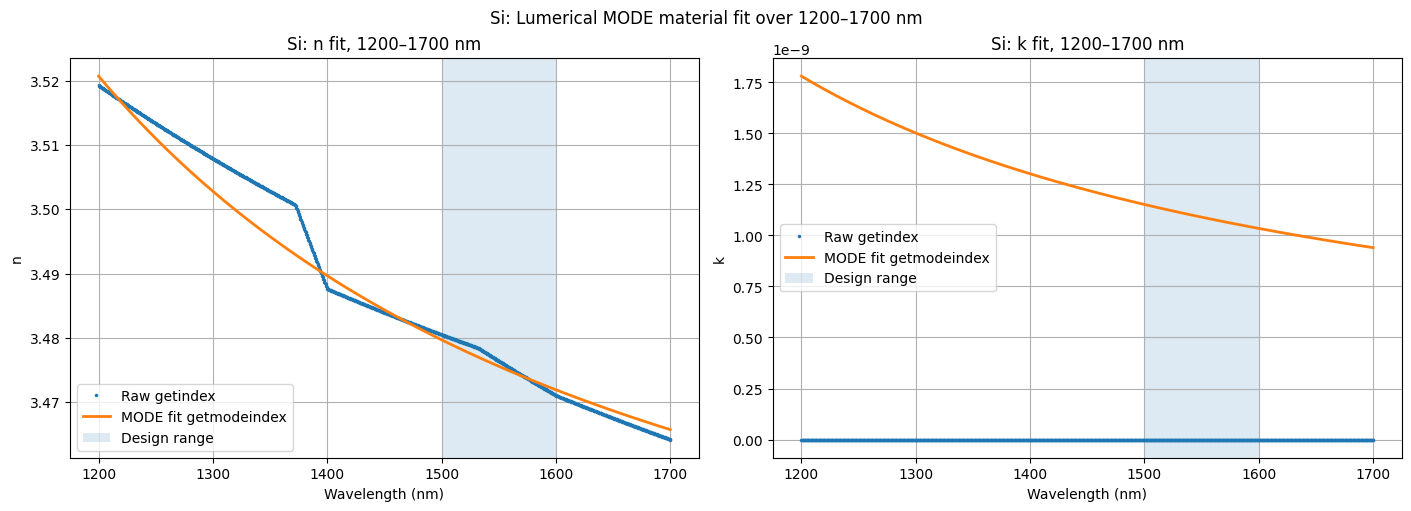

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_MODE_fit_1200_1700nm.png


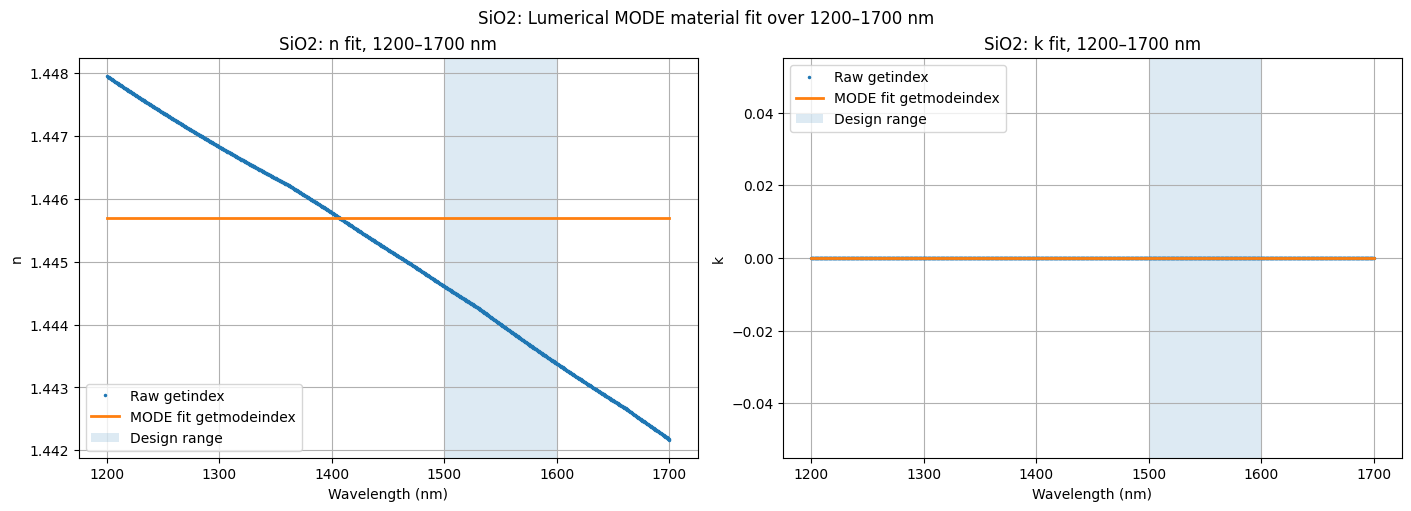

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_MODE_fit_1200_1700nm.png


In [6]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[0].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[0].set_title(f"{label}: n fit, 1200–1700 nm")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[1].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[1].set_title(f"{label}: k fit, 1200–1700 nm")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    fig.suptitle(f"{label}: Lumerical MODE material fit over 1200–1700 nm")

    plot_path = material_dir / f"{label}_MODE_fit_1200_1700nm.png"
    fig.savefig(plot_path, dpi=300)

    plt.show()

    print("Saved:", plot_path)

## Material values at 1550 nm

In [7]:
lambda0_nm = settings["wavelength_um"] * 1000.0

material_at_lambda0 = {}

for label, d in material_data.items():

    n0 = np.interp(lambda0_nm, d["lambda_nm"], d["n"])
    k0 = np.interp(lambda0_nm, d["lambda_nm"], d["k"])
    ng0 = np.interp(lambda0_nm, d["lambda_nm"], d["ng"])
    eps_energy0 = np.interp(lambda0_nm, d["lambda_nm"], d["eps_energy"])

    material_at_lambda0[label] = {
        "n": n0,
        "k": k0,
        "ng": ng0,
        "eps_energy": eps_energy0,
    }

print(f"Material values at lambda = {lambda0_nm:.1f} nm")
print("Values are from MODE multi-coefficient fit over 1200–1700 nm.\n")

for label, d in material_at_lambda0.items():
    print(
        f"{label}: "
        f"n = {d['n']:.8f}, "
        f"k = {d['k']:.3e}, "
        f"ng_material = {d['ng']:.8f}, "
        f"eps_energy = {d['eps_energy']:.8f}"
    )

Material values at lambda = 1550.0 nm
Values are from MODE multi-coefficient fit over 1200–1700 nm.

Si: n = 3.47554455, k = 1.090e-09, ng_material = 3.59578939, eps_energy = 12.91524254
SiO2: n = 1.44569554, k = 0.000e+00, ng_material = 1.44569554, eps_energy = 2.09003561


## Function cell: compact build + data extractor

In [8]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def squeeze_arr(a):
    return np.squeeze(np.array(a))


def real_arr(a):
    return np.real(squeeze_arr(a))


def scalar_or_nan(x):
    try:
        x = np.squeeze(np.array(x))

        if x.size == 0:
            return np.nan

        return np.real(x.item())

    except Exception:
        return np.nan


def trapz2(f, x, y):
    return np.trapz(
        np.trapz(f, y, axis=1),
        x,
        axis=0,
    )


def positive_weight(F):
    return np.maximum(np.real(F), 0.0)


def calc_mode_metrics_from_E2(x_um, y_um, Ex, Ey, Ez):
    """
    Calculates mode area and MFD from |E|^2.

    x_um and y_um are in microns.

    MFD definition:
        MFD_x = 4 sigma_x
        MFD_y = 4 sigma_y
    """

    E2 = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    F = positive_weight(E2)

    total = trapz2(F, x_um, y_um)

    if total <= 0 or not np.isfinite(total):
        return {
            "mode_area_E2_um2": np.nan,
            "xbar_E2_um": np.nan,
            "ybar_E2_um": np.nan,
            "MFD_E2_x_um": np.nan,
            "MFD_E2_y_um": np.nan,
        }

    X, Y = np.meshgrid(x_um, y_um, indexing="ij")

    xbar = trapz2(F * X, x_um, y_um) / total
    ybar = trapz2(F * Y, x_um, y_um) / total

    sigma_x = np.sqrt(
        trapz2(F * (X - xbar)**2, x_um, y_um) / total
    )

    sigma_y = np.sqrt(
        trapz2(F * (Y - ybar)**2, x_um, y_um) / total
    )

    MFD_x = 4.0 * sigma_x
    MFD_y = 4.0 * sigma_y

    denom = trapz2(F**2, x_um, y_um)

    if denom <= 0 or not np.isfinite(denom):
        area = np.nan
    else:
        area = total**2 / denom

    return {
        "mode_area_E2_um2": area,
        "xbar_E2_um": xbar,
        "ybar_E2_um": ybar,
        "MFD_E2_x_um": MFD_x,
        "MFD_E2_y_um": MFD_y,
    }


def get_mode_data(mode_obj, mode_number, quantity):
    return squeeze_arr(
        mode_obj.getdata(f"FDE::data::mode{mode_number}", quantity)
    )


def get_from_mode_or_list(mode_obj, mode_number, key, default=np.nan):
    try:
        return mode_obj.getdata(f"FDE::data::mode{mode_number}", key)

    except Exception:
        pass

    try:
        return mode_obj.getdata("FDE::data", key)[mode_number - 1]

    except Exception:
        return default


def get_te_fraction(mode_obj, mode_number):
    """
    Try common Lumerical TE-fraction result names.
    """

    keys = [
        "waveguide TE fraction",
        "TE polarization fraction",
        "waveguide TE/TM fraction",
    ]

    for key in keys:

        value = get_from_mode_or_list(
            mode_obj,
            mode_number,
            key,
            default=np.nan,
        )

        value = scalar_or_nan(value)

        if np.isfinite(value):
            return value

    return np.nan


def is_guided_mode(neff_real, n_clad, tolerance):
    return neff_real > n_clad + tolerance


def build_single_wg_fde_model(mode_obj, settings_local, width_um, lms_file_path=None):
    """
    Build one complete FDE model for a given width.

    This function is used by both:
        1. sequential sweep
        2. parallel sweep

    In parallel mode, each worker opens its own MODE session and calls this.
    """

    um_local = 1e-6

    mode_obj.switchtolayout()
    mode_obj.deleteall()

    # ------------------------------
    # SiO2 box
    # ------------------------------
    mode_obj.addrect()
    mode_obj.set("name", "SiO2_box")
    mode_obj.set("material", settings_local["sio2_material_name"])

    mode_obj.set("x", 0.0)
    mode_obj.set("y", 0.0)
    mode_obj.set("z", 0.0)

    mode_obj.set("x span", settings_local["oxide_x_span_um"] * um_local)
    mode_obj.set("y span", settings_local["oxide_y_span_um"] * um_local)
    mode_obj.set("z span", settings_local["z_span_um"] * um_local)

    # ------------------------------
    # Si waveguide
    # ------------------------------
    mode_obj.addrect()
    mode_obj.set("name", "Si_waveguide")
    mode_obj.set("material", settings_local["si_material_name"])

    mode_obj.set("x", settings_local["wg_center_x_um"] * um_local)
    mode_obj.set("y", settings_local["wg_center_y_um"] * um_local)
    mode_obj.set("z", 0.0)

    mode_obj.set("x span", width_um * um_local)
    mode_obj.set("y span", settings_local["wg_thickness_um"] * um_local)
    mode_obj.set("z span", settings_local["z_span_um"] * um_local)

    # ------------------------------
    # FDE solver
    # ------------------------------
    mode_obj.addfde()

    mode_obj.set("solver type", "2D Z normal")

    mode_obj.set("x", settings_local["fde_center_x_um"] * um_local)
    mode_obj.set("y", settings_local["fde_center_y_um"] * um_local)

    mode_obj.set("x span", settings_local["fde_x_span_um"] * um_local)
    mode_obj.set("y span", settings_local["fde_y_span_um"] * um_local)

    mode_obj.set("wavelength", settings_local["wavelength_um"] * um_local)

    bc = settings_local["fde_bc"]

    mode_obj.set("x min bc", bc)
    mode_obj.set("x max bc", bc)
    mode_obj.set("y min bc", bc)
    mode_obj.set("y max bc", bc)

    mode_obj.set(
        "number of trial modes",
        settings_local["number_of_trial_modes"],
    )

    mode_obj.set("define x mesh by", "maximum mesh step")
    mode_obj.set("define y mesh by", "maximum mesh step")

    mode_obj.set("dx", settings_local["fde_dx_um"] * um_local)
    mode_obj.set("dy", settings_local["fde_dy_um"] * um_local)

    # ------------------------------
    # Optional extra mesh
    # ------------------------------
    if settings_local["use_extra_mesh"]:

        mesh_x_span_um = width_um + 2.0 * settings_local["mesh_extra_x_um"]
        mesh_y_span_um = settings_local["mesh_y_span_um"]

        mode_obj.addmesh()
        mode_obj.set("name", settings_local["extra_mesh_name"])

        mode_obj.set("x", settings_local["wg_center_x_um"] * um_local)
        mode_obj.set("y", settings_local["wg_center_y_um"] * um_local)
        mode_obj.set("z", 0.0)

        mode_obj.set("x span", mesh_x_span_um * um_local)
        mode_obj.set("y span", mesh_y_span_um * um_local)
        mode_obj.set("z span", settings_local["z_span_um"] * um_local)

        mode_obj.set("override x mesh", 1)
        mode_obj.set("override y mesh", 1)

        mode_obj.set("dx", settings_local["local_dx_um"] * um_local)
        mode_obj.set("dy", settings_local["local_dy_um"] * um_local)

    if lms_file_path is not None:
        mode_obj.save(str(lms_file_path))


def extract_single_wg_mode_data(
    mode_obj,
    settings_local,
    material_at_lambda0_local,
    width_um,
):
    """
    Extracts compact mode data after mode_obj.findmodes().

    Does not save fields.
    Reads Ex/Ey/Ez only temporarily to compute MFD.
    """

    um_local = 1e-6

    rows = []

    num_modes = int(settings_local["number_of_trial_modes"])

    n_clad = material_at_lambda0_local["SiO2"]["n"]
    n_core = material_at_lambda0_local["Si"]["n"]

    for m in range(1, num_modes + 1):

        neff = get_from_mode_or_list(
            mode_obj,
            m,
            "neff",
            default=np.nan,
        )

        if np.all(pd.isna(neff)):
            continue

        neff_complex = complex(np.squeeze(neff))
        neff_real = np.real(neff_complex)
        neff_imag = np.imag(neff_complex)

        ng = get_from_mode_or_list(
            mode_obj,
            m,
            "ng",
            default=np.nan,
        )

        if np.all(pd.isna(ng)):
            ng_complex = np.nan
            ng_real = np.nan
        else:
            ng_complex = complex(np.squeeze(ng))
            ng_real = np.real(ng_complex)

        loss = get_from_mode_or_list(
            mode_obj,
            m,
            "loss",
            default=np.nan,
        )

        loss_dB_per_cm = scalar_or_nan(loss)

        TE_fraction = get_te_fraction(mode_obj, m)

        guided = is_guided_mode(
            neff_real=neff_real,
            n_clad=n_clad,
            tolerance=settings_local["guided_neff_tolerance"],
        )

        try:
            x_um = real_arr(get_mode_data(mode_obj, m, "x")) / um_local
            y_um = real_arr(get_mode_data(mode_obj, m, "y")) / um_local

            Ex = np.squeeze(get_mode_data(mode_obj, m, "Ex"))
            Ey = np.squeeze(get_mode_data(mode_obj, m, "Ey"))
            Ez = np.squeeze(get_mode_data(mode_obj, m, "Ez"))

            mfd_metrics = calc_mode_metrics_from_E2(
                x_um,
                y_um,
                Ex,
                Ey,
                Ez,
            )

        except Exception as e:
            print(
                f"Warning: MFD failed for width={width_um:.4f} um, mode={m}"
            )
            print(e)

            mfd_metrics = {
                "mode_area_E2_um2": np.nan,
                "xbar_E2_um": np.nan,
                "ybar_E2_um": np.nan,
                "MFD_E2_x_um": np.nan,
                "MFD_E2_y_um": np.nan,
            }

        row = {
            "width_um": float(width_um),
            "thickness_um": float(settings_local["wg_thickness_um"]),
            "wavelength_um": float(settings_local["wavelength_um"]),

            "mode_number": int(m),
            "is_guided": bool(guided),

            "neff": neff_complex,
            "neff_real": float(neff_real),
            "neff_imag": float(neff_imag),

            "ng": ng_complex,
            "ng_real": float(ng_real) if np.isfinite(ng_real) else np.nan,

            "loss_dB_per_cm": (
                float(loss_dB_per_cm)
                if np.isfinite(loss_dB_per_cm)
                else np.nan
            ),

            "TE_fraction": (
                float(TE_fraction)
                if np.isfinite(TE_fraction)
                else np.nan
            ),

            "n_Si_1550": float(n_core),
            "n_SiO2_1550": float(n_clad),
        }

        row.update(mfd_metrics)

        rows.append(row)

    return pd.DataFrame(rows)


def single_wg_mode_sequential(width_um, save_lms=False, lms_file_path=None):
    """
    Sequential version.

    Uses the already-open global `mode` session.
    Good for debugging and safest for one license.
    """

    if save_lms:
        local_lms_path = lms_file_path
    else:
        local_lms_path = None

    build_single_wg_fde_model(
        mode_obj=mode,
        settings_local=settings,
        width_um=float(width_um),
        lms_file_path=local_lms_path,
    )

    mode.findmodes()

    df_width = extract_single_wg_mode_data(
        mode_obj=mode,
        settings_local=settings,
        material_at_lambda0_local=material_at_lambda0,
        width_um=float(width_um),
    )

    return df_width


def single_wg_mode_worker(args):
    """
    Parallel worker.

    Important:
    - Opens a new MODE session inside each worker.
    - Builds model for one width.
    - Solves modes.
    - Extracts compact metrics.
    - Closes the session.

    This is the safe way to parallelize Lumerical jobs.
    """

    (
        width_um,
        settings_local,
        material_at_lambda0_local,
        lumerical_python_api,
        worker_run_dir,
    ) = args

    import os
    import sys
    from pathlib import Path
    import numpy as np
    import pandas as pd

    if lumerical_python_api not in sys.path:
        sys.path.append(lumerical_python_api)

    import lumapi

    width_um = float(width_um)

    worker_run_dir = Path(worker_run_dir)
    worker_run_dir.mkdir(exist_ok=True, parents=True)

    width_tag = f"{width_um:.4f}".replace(".", "p")

    lms_path = worker_run_dir / f"single_wg_width_{width_tag}um.lms"

    mode_local = None

    try:
        mode_local = lumapi.MODE(hide=settings_local["hide_lumerical"])
        mode_local.newproject()

        build_single_wg_fde_model(
            mode_obj=mode_local,
            settings_local=settings_local,
            width_um=width_um,
            lms_file_path=lms_path,
        )

        mode_local.findmodes()

        df_width = extract_single_wg_mode_data(
            mode_obj=mode_local,
            settings_local=settings_local,
            material_at_lambda0_local=material_at_lambda0_local,
            width_um=width_um,
        )

        df_width["worker_lms_file"] = str(lms_path)
        df_width["status"] = "success"
        df_width["error"] = ""

    except Exception as e:

        df_width = pd.DataFrame([{
            "width_um": width_um,
            "status": "failed",
            "error": str(e),
        }])

    finally:
        try:
            if mode_local is not None:
                mode_local.close()
        except Exception:
            pass

    return df_width


print("Function cell loaded.")
print("Available functions:")
print("  single_wg_mode_sequential(width_um)")
print("  single_wg_mode_worker(args)")

Function cell loaded.
Available functions:
  single_wg_mode_sequential(width_um)
  single_wg_mode_worker(args)


## Sweep cell: parallel or sequential

In [9]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Sweep control
# ------------------------------------------------------------
use_parallel = True

# For parallel:
# Usually start with 2.
# Increase only if you have enough RAM and enough Lumerical license capacity.
max_workers = 2

widths_um = np.linspace(
    settings["width_start_um"],
    settings["width_stop_um"],
    settings["width_num_points"],
)

# ------------------------------------------------------------
# Create run folders
# ------------------------------------------------------------
project_root = Path.cwd()

simulation_runs_dir = project_root / "simulation_runs"
simulation_runs_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

run_dir = simulation_runs_dir / f"{settings['folder_name']}_{timestamp}"
run_dir.mkdir(exist_ok=False)

csv_dir = run_dir / "csv"
plot_dir = run_dir / "plots"
lms_dir = run_dir / "lms_files"

csv_dir.mkdir(exist_ok=True)
plot_dir.mkdir(exist_ok=True)
lms_dir.mkdir(exist_ok=True)

settings_path = run_dir / "settings.csv"
widths_path = run_dir / "widths.csv"

pd.DataFrame(
    [{"key": k, "value": v} for k, v in settings.items()]
).to_csv(settings_path, index=False)

pd.DataFrame(
    {"width_um": widths_um}
).to_csv(widths_path, index=False)

print("Run directory:")
print(run_dir)

print(f"use_parallel = {use_parallel}")
print(f"max_workers = {max_workers}")
print(f"Number of width points = {len(widths_um)}")


# ------------------------------------------------------------
# Sequential sweep
# ------------------------------------------------------------
if not use_parallel:

    all_dfs = []

    for i, width_um in enumerate(widths_um, start=1):

        print("=" * 80)
        print(f"[{i}/{len(widths_um)}] width = {width_um:.4f} um")

        try:
            lms_file_path = lms_dir / f"single_wg_width_{width_um:.4f}um.lms"

            df_width = single_wg_mode_sequential(
                width_um=float(width_um),
                save_lms=True,
                lms_file_path=lms_file_path,
            )

            df_width["status"] = "success"
            df_width["error"] = ""
            df_width["worker_lms_file"] = str(lms_file_path)

        except Exception as e:

            df_width = pd.DataFrame([{
                "width_um": float(width_um),
                "status": "failed",
                "error": str(e),
            }])

        width_csv_path = csv_dir / f"width_{width_um:.4f}um_modes.csv"
        df_width.to_csv(width_csv_path, index=False)

        all_dfs.append(df_width)

        if "mode_number" in df_width.columns:

            display_cols = [
                "width_um",
                "mode_number",
                "is_guided",
                "neff_real",
                "ng_real",
                "MFD_E2_x_um",
                "MFD_E2_y_um",
                "TE_fraction",
            ]

            existing_display_cols = [
                col for col in display_cols if col in df_width.columns
            ]

            print(df_width[existing_display_cols].to_string(index=False))

        else:
            print(df_width.to_string(index=False))


# ------------------------------------------------------------
# Parallel sweep
# ------------------------------------------------------------
else:

    try:
        from joblib import Parallel, delayed
    except ImportError as e:
        raise ImportError(
            "joblib is needed for parallel sweep. Install with:\n"
            "pip install joblib\n\n"
            "Or set use_parallel = False."
        ) from e

    worker_args = []

    for width_um in widths_um:

        worker_args.append((
            float(width_um),
            settings,
            material_at_lambda0,
            LUMERICAL_PYTHON_API,
            str(lms_dir),
        ))

    print("Launching parallel MODE workers...")
    print("Each worker opens its own MODE session.")

    all_dfs = Parallel(
        n_jobs=max_workers,
        backend="loky",
        verbose=10,
    )(
        delayed(single_wg_mode_worker)(args)
        for args in worker_args
    )

    for df_width in all_dfs:

        if "width_um" in df_width.columns:
            width_um = float(df_width["width_um"].iloc[0])
        else:
            width_um = np.nan

        width_csv_path = csv_dir / f"width_{width_um:.4f}um_modes.csv"
        df_width.to_csv(width_csv_path, index=False)


# ------------------------------------------------------------
# Combine and save all results
# ------------------------------------------------------------
if len(all_dfs) == 0:
    raise RuntimeError("No width points were simulated.")

df_all = pd.concat(all_dfs, ignore_index=True)

df_all = df_all.sort_values(
    by=["width_um", "mode_number"] if "mode_number" in df_all.columns else ["width_um"],
    ascending=True,
).reset_index(drop=True)

combined_csv_path = run_dir / "all_widths_modes_metrics.csv"
df_all.to_csv(combined_csv_path, index=False)

print("=" * 80)
print("Sweep finished.")
print("Saved combined metrics:")
print(combined_csv_path)

df_all

Run directory:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502
use_parallel = True
max_workers = 2
Number of width points = 15
Launching parallel MODE workers...
Each worker opens its own MODE session.


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  5.1min
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed: 16.2min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed: 31.8min


Sweep finished.
Saved combined metrics:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\all_widths_modes_metrics.csv


[Parallel(n_jobs=2)]: Done  15 out of  15 | elapsed: 34.9min finished


,width_um,thickness_um,wavelength_um,mode_number,is_guided,neff,neff_real,neff_imag,ng,ng_real,...,n_Si_1550,n_SiO2_1550,mode_area_E2_um2,xbar_E2_um,ybar_E2_um,MFD_E2_x_um,MFD_E2_y_um,worker_lms_file,status,error
0,0.220000,0.22,1.55,1,True,1.513797+0.000000j,1.513797,1.203226e-16,2.248572-0.000000j,2.248572,...,3.475545,1.445696,0.636037,-8.166528e-15,5.167988e-15,1.430696,1.239785,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
1,0.220000,0.22,1.55,2,True,1.513782-0.000000j,1.513782,-7.889639e-18,2.248471-0.000000j,2.248471,...,3.475545,1.445696,0.635973,7.310464e-15,-3.285774e-15,1.239887,1.430806,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
2,0.275714,0.22,1.55,1,True,1.709131+0.000000j,1.709131,1.467434e-16,3.676652+0.000000j,3.676652,...,3.475545,1.445696,0.302415,1.545704e-15,1.163018e-15,0.907595,0.653867,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
3,0.275714,0.22,1.55,2,True,1.568228+0.000000j,1.568228,3.574190e-16,2.706531+0.000000j,2.706531,...,3.475545,1.445696,0.450952,1.295708e-15,4.562614e-15,0.944791,1.152682,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
4,0.331429,0.22,1.55,1,True,1.973252+0.000000j,1.973252,1.326758e-16,4.416721-0.000000j,4.416721,...,3.475545,1.445696,0.238724,1.129573e-15,8.875328e-16,0.758948,0.491538,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
5,0.331429,0.22,1.55,2,True,1.625948-0.000000j,1.625948,-1.482435e-16,3.105864-0.000000j,3.105864,...,3.475545,1.445696,0.383155,1.362479e-15,3.492372e-15,0.812594,1.014528,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
6,0.387143,0.22,1.55,1,True,2.186759+0.000000j,2.186759,5.303104e-17,4.456196-0.000000j,4.456196,...,3.475545,1.445696,0.213003,1.383435e-16,1.283529e-15,0.706153,0.432513,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
7,0.387143,0.22,1.55,2,True,1.680407-0.000000j,1.680407,-9.440854e-18,3.409171-0.000000j,3.409171,...,3.475545,1.445696,0.357033,-6.648065e-16,2.575901e-15,0.754143,0.936214,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
8,0.442857,0.22,1.55,1,True,2.336732-0.000000j,2.336732,-5.591552e-17,4.350274-0.000000j,4.350274,...,3.475545,1.445696,0.198292,-1.122903e-15,6.202627e-16,0.685062,0.404699,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,
9,0.442857,0.22,1.55,2,True,1.729028-0.000000j,1.729028,-1.067090e-16,3.627032-0.000000j,3.627032,...,3.475545,1.445696,0.348723,-1.444427e-15,-6.049766e-16,0.732332,0.886938,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,


## Plotting cell

Saved TE/TM sorted table:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\all_widths_modes_TE_TM_sorted.csv


,width_um,mode_number,branch,polarization_class,polarization_order,neff_real,ng_real,MFD_E2_x_um,MFD_E2_y_um,TE_fraction
0,0.220000,1,TE0,TE,0,1.513797,2.248572,1.430696,1.239785,0.967001
1,0.220000,2,TM0,TM,0,1.513782,2.248471,1.239887,1.430806,0.033005
2,0.275714,1,TE0,TE,0,1.709131,3.676652,0.907595,0.653867,0.941715
3,0.275714,2,TM0,TM,0,1.568228,2.706531,0.944791,1.152682,0.041661
4,0.331429,1,TE0,TE,0,1.973252,4.416721,0.758948,0.491538,0.947417
5,0.331429,2,TM0,TM,0,1.625948,3.105864,0.812594,1.014528,0.045673
6,0.387143,1,TE0,TE,0,2.186759,4.456196,0.706153,0.432513,0.963399
7,0.387143,2,TM0,TM,0,1.680407,3.409171,0.754143,0.936214,0.046673
8,0.442857,1,TE0,TE,0,2.336732,4.350274,0.685062,0.404699,0.975891
9,0.442857,3,TE1,TE,1,1.446461,1.805960,4.713445,3.968502,0.637462


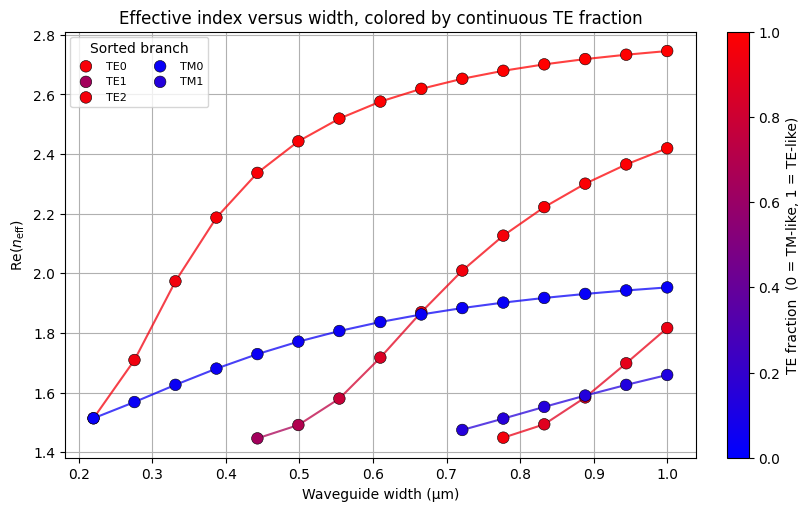

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\neff_vs_width_continuous_TE_fraction.png


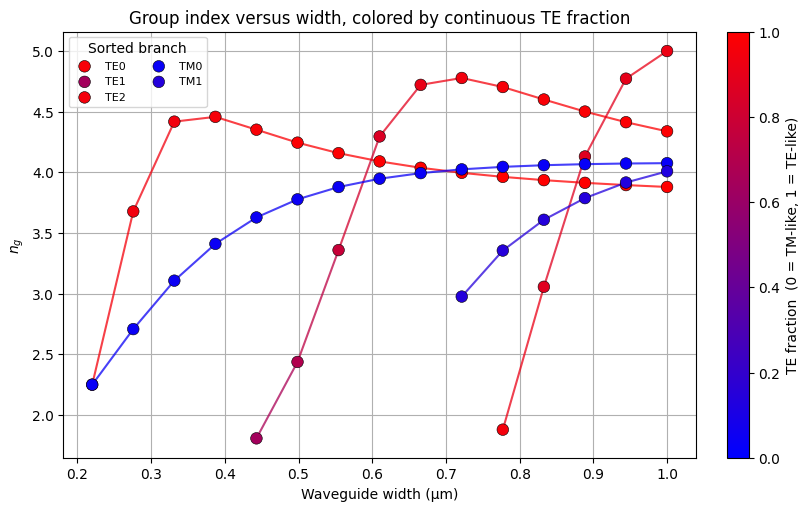

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\ng_vs_width_continuous_TE_fraction.png


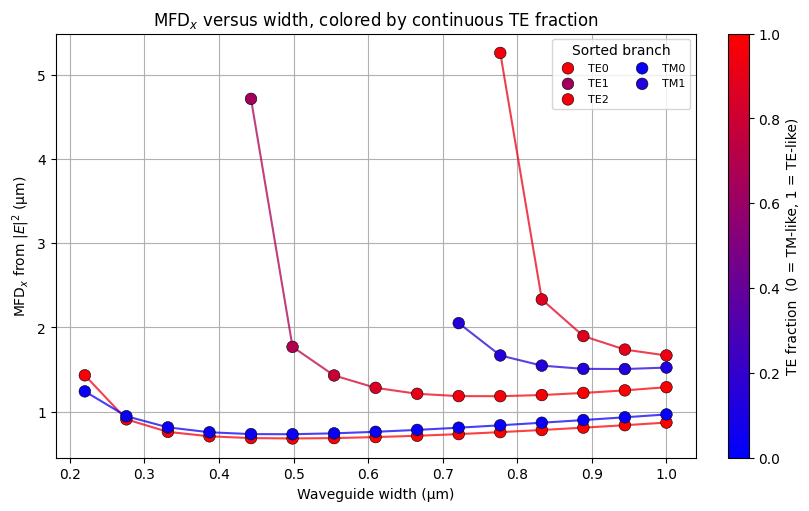

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\MFDx_vs_width_continuous_TE_fraction.png


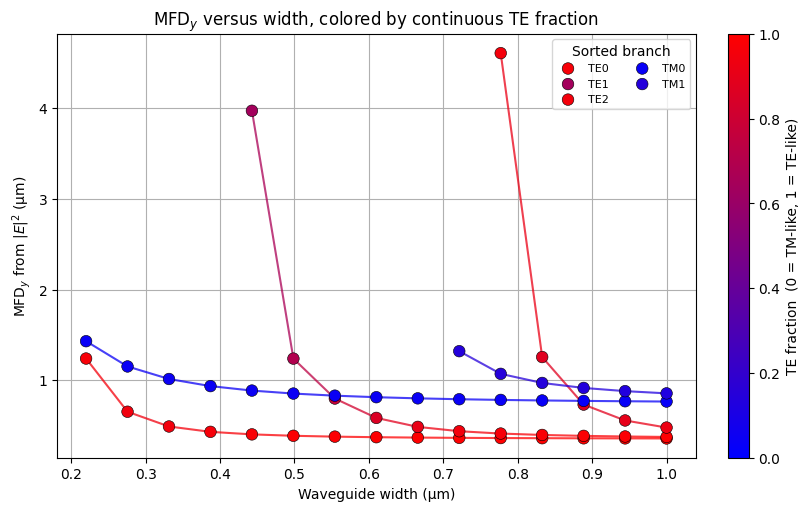

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\MFDy_vs_width_continuous_TE_fraction.png


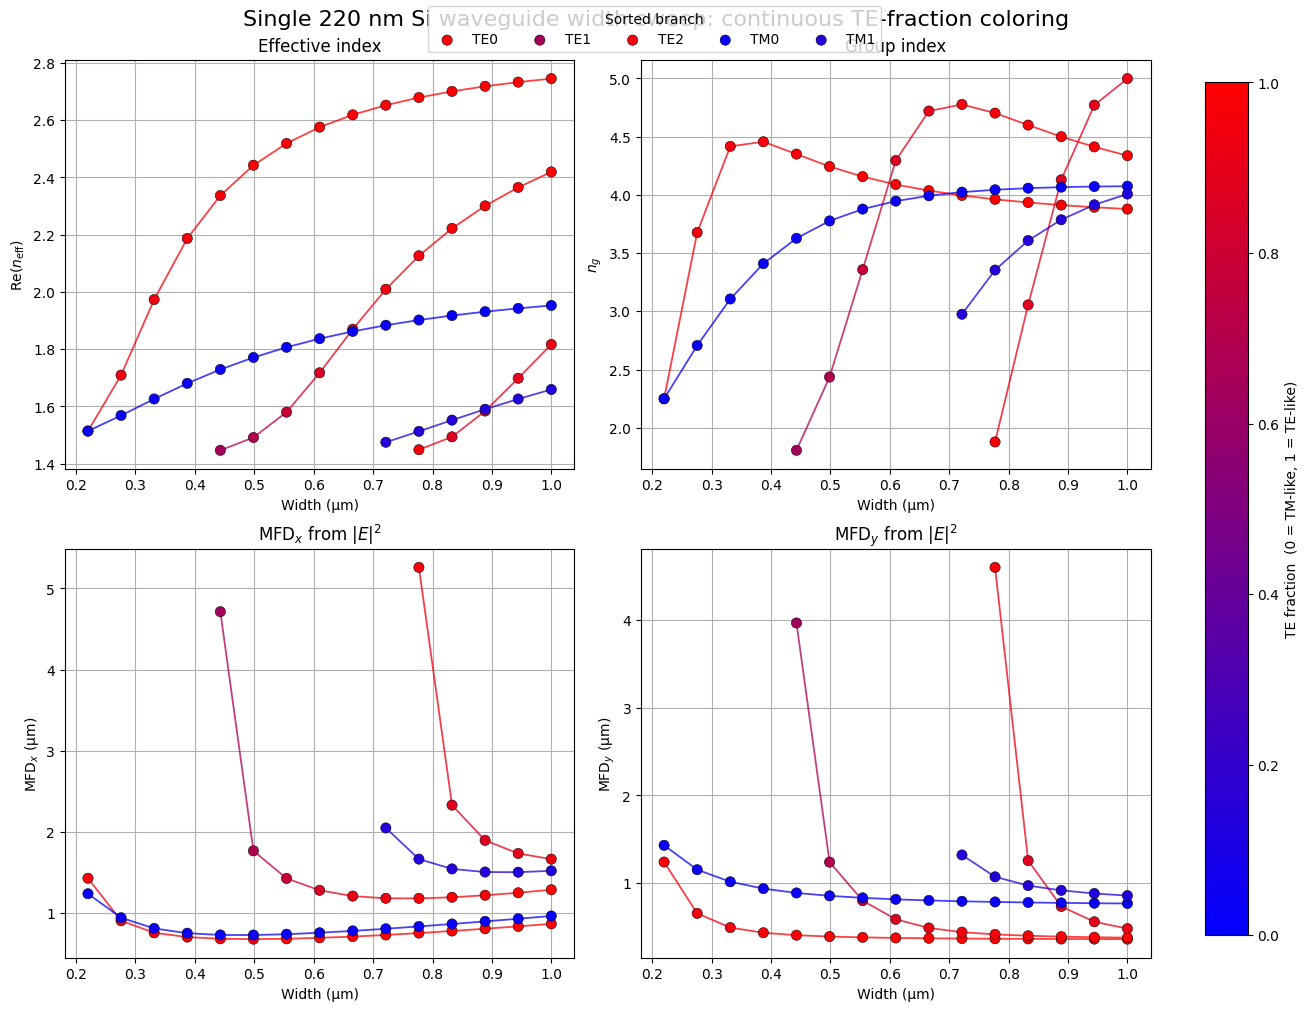

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\combined_metrics_vs_width_continuous_TE_fraction.png


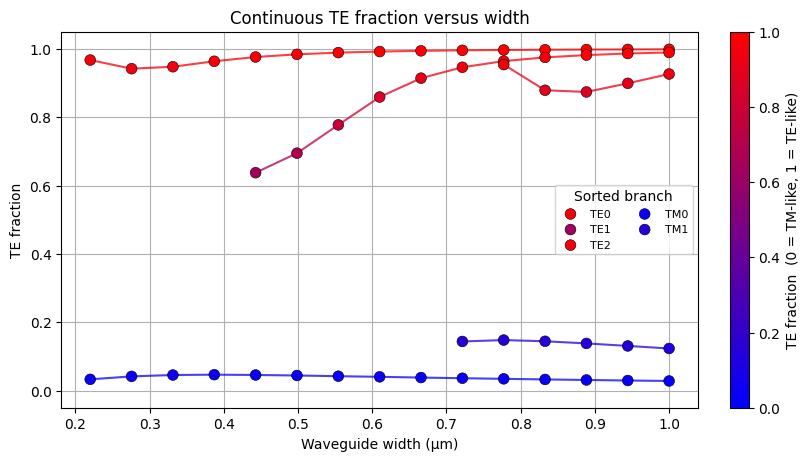

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_sweep_20260615_212502\plots\TE_fraction_vs_width_continuous.png


,width_um,thickness_um,wavelength_um,mode_number,is_guided,neff,neff_real,neff_imag,ng,ng_real,...,xbar_E2_um,ybar_E2_um,MFD_E2_x_um,MFD_E2_y_um,worker_lms_file,status,error,polarization_class,polarization_order,branch
0,0.220000,0.22,1.55,1,True,1.513797+0.000000j,1.513797,1.203226e-16,2.248572-0.000000j,2.248572,...,-8.166528e-15,5.167988e-15,1.430696,1.239785,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,0,TE0
1,0.220000,0.22,1.55,2,True,1.513782-0.000000j,1.513782,-7.889639e-18,2.248471-0.000000j,2.248471,...,7.310464e-15,-3.285774e-15,1.239887,1.430806,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TM,0,TM0
2,0.275714,0.22,1.55,1,True,1.709131+0.000000j,1.709131,1.467434e-16,3.676652+0.000000j,3.676652,...,1.545704e-15,1.163018e-15,0.907595,0.653867,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,0,TE0
3,0.275714,0.22,1.55,2,True,1.568228+0.000000j,1.568228,3.574190e-16,2.706531+0.000000j,2.706531,...,1.295708e-15,4.562614e-15,0.944791,1.152682,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TM,0,TM0
4,0.331429,0.22,1.55,1,True,1.973252+0.000000j,1.973252,1.326758e-16,4.416721-0.000000j,4.416721,...,1.129573e-15,8.875328e-16,0.758948,0.491538,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,0,TE0
5,0.331429,0.22,1.55,2,True,1.625948-0.000000j,1.625948,-1.482435e-16,3.105864-0.000000j,3.105864,...,1.362479e-15,3.492372e-15,0.812594,1.014528,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TM,0,TM0
6,0.387143,0.22,1.55,1,True,2.186759+0.000000j,2.186759,5.303104e-17,4.456196-0.000000j,4.456196,...,1.383435e-16,1.283529e-15,0.706153,0.432513,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,0,TE0
7,0.387143,0.22,1.55,2,True,1.680407-0.000000j,1.680407,-9.440854e-18,3.409171-0.000000j,3.409171,...,-6.648065e-16,2.575901e-15,0.754143,0.936214,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TM,0,TM0
8,0.442857,0.22,1.55,1,True,2.336732-0.000000j,2.336732,-5.591552e-17,4.350274-0.000000j,4.350274,...,-1.122903e-15,6.202627e-16,0.685062,0.404699,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,0,TE0
9,0.442857,0.22,1.55,3,True,1.446461-0.000000j,1.446461,-4.622691e-08,1.805960+0.000015j,1.805960,...,1.090106e-12,-1.952245e-12,4.713445,3.968502,c:\Users\Amirali\Desktop\Beam_Splitter_Project...,success,,TE,1,TE1


In [10]:
# %% [markdown]
# ## Plot sweep results using TE/TM sorted branches
# ## Continuous TE-fraction color: blue = TM-like, red = TE-like

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable


# ------------------------------------------------------------
# TE/TM sorting settings
# ------------------------------------------------------------
te_threshold = 0.5

# Sort modes inside each polarization group by this quantity.
# Usually neff_real is best because the fundamental mode has highest neff.
sort_modes_by = "neff_real"

# Descending means highest neff becomes TE0 or TM0.
sort_descending = True

# Continuous colormap:
# TE_fraction = 0 -> blue
# TE_fraction = 1 -> red
te_fraction_cmap = LinearSegmentedColormap.from_list(
    "tm_to_te_blue_red",
    ["blue", "red"],
)

te_fraction_norm = Normalize(vmin=0.0, vmax=1.0)


def prepare_te_tm_sorted_branches(
    df,
    te_threshold=0.5,
    sort_modes_by="neff_real",
    sort_descending=True,
    guided_only=True,
):
    """
    For each width:
        - keep successful rows
        - optionally keep guided modes only
        - split modes into TE-like and TM-like using TE_fraction
        - sort each group by sort_modes_by
        - assign branch labels TE0, TE1, ... and TM0, TM1, ...

    Important:
        The TE/TM threshold is used only for branch naming/order.
        Plot color is NOT discretized.
        Plot color uses the continuous TE_fraction value.
    """

    d = df.copy()

    if "status" in d.columns:
        d = d[d["status"] == "success"].copy()

    if guided_only and "is_guided" in d.columns:
        d = d[d["is_guided"]].copy()

    required_cols = [
        "width_um",
        "mode_number",
        "TE_fraction",
        sort_modes_by,
    ]

    for col in required_cols:
        if col not in d.columns:
            raise ValueError(f"Missing required column: {col}")

    d = d[np.isfinite(d["TE_fraction"])].copy()
    d = d[np.isfinite(d[sort_modes_by])].copy()

    rows = []

    for width_um, g in d.groupby("width_um"):

        g = g.copy()

        te_like = g[g["TE_fraction"] >= te_threshold].copy()
        tm_like = g[g["TE_fraction"] < te_threshold].copy()

        te_like = te_like.sort_values(
            sort_modes_by,
            ascending=not sort_descending,
        ).reset_index(drop=True)

        tm_like = tm_like.sort_values(
            sort_modes_by,
            ascending=not sort_descending,
        ).reset_index(drop=True)

        for k, (_, row) in enumerate(te_like.iterrows()):
            row = row.copy()
            row["polarization_class"] = "TE"
            row["polarization_order"] = int(k)
            row["branch"] = f"TE{k}"
            rows.append(row)

        for k, (_, row) in enumerate(tm_like.iterrows()):
            row = row.copy()
            row["polarization_class"] = "TM"
            row["polarization_order"] = int(k)
            row["branch"] = f"TM{k}"
            rows.append(row)

    df_sorted = pd.DataFrame(rows)

    if len(df_sorted) == 0:
        raise RuntimeError("No sorted TE/TM mode rows were produced.")

    df_sorted = df_sorted.sort_values(
        ["width_um", "polarization_class", "polarization_order"]
    ).reset_index(drop=True)

    return df_sorted


def sort_branch_names(branches):
    """
    Sort branch names as:
        TE0, TE1, TE2, ...
        TM0, TM1, TM2, ...
    """

    return sorted(
        branches,
        key=lambda s: (
            0 if str(s).startswith("TE") else 1,
            int(str(s)[2:]) if len(str(s)) > 2 and str(s)[2:].isdigit() else 999,
        ),
    )


def add_te_fraction_colored_line(
    ax,
    x,
    y,
    te_fraction,
    linewidth=1.5,
    alpha=0.75,
):
    """
    Add a line whose segment color follows continuous TE_fraction.

    The color of each line segment is the average TE_fraction
    of its two endpoints.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    te_fraction = np.asarray(te_fraction, dtype=float)

    if len(x) < 2:
        return None

    points = np.array([x, y]).T.reshape(-1, 1, 2)

    segments = np.concatenate(
        [points[:-1], points[1:]],
        axis=1,
    )

    segment_te = 0.5 * (te_fraction[:-1] + te_fraction[1:])

    lc = LineCollection(
        segments,
        cmap=te_fraction_cmap,
        norm=te_fraction_norm,
        linewidth=linewidth,
        alpha=alpha,
    )

    lc.set_array(segment_te)

    ax.add_collection(lc)

    return lc


df_plot = prepare_te_tm_sorted_branches(
    df=df_all,
    te_threshold=te_threshold,
    sort_modes_by=sort_modes_by,
    sort_descending=sort_descending,
    guided_only=settings["plot_guided_only"],
)

sorted_csv_path = run_dir / "all_widths_modes_TE_TM_sorted.csv"
df_plot.to_csv(sorted_csv_path, index=False)

print("Saved TE/TM sorted table:")
print(sorted_csv_path)

display(
    df_plot[
        [
            "width_um",
            "mode_number",
            "branch",
            "polarization_class",
            "polarization_order",
            "neff_real",
            "ng_real",
            "MFD_E2_x_um",
            "MFD_E2_y_um",
            "TE_fraction",
        ]
    ]
)


def plot_metric_vs_width_te_fraction(
    df_sorted,
    metric_col,
    ylabel,
    title,
    save_name,
):
    """
    Plot metric versus width.

    Branches:
        TE0, TE1, TM0, TM1, ...

    Marker:
        same marker for all branches

    Color:
        continuous TE_fraction
        blue = TM-like
        red = TE-like
    """

    d = df_sorted.copy()

    required_cols = [
        "width_um",
        "branch",
        metric_col,
        "TE_fraction",
    ]

    for col in required_cols:
        if col not in d.columns:
            print(f"Missing column {col}. Cannot plot {metric_col}.")
            return

    d = d[np.isfinite(d[metric_col])].copy()
    d = d[np.isfinite(d["TE_fraction"])].copy()

    if len(d) == 0:
        print(f"No data to plot for {metric_col}")
        return

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

    branches = sort_branch_names(d["branch"].unique())

    for branch in branches:

        db = d[d["branch"] == branch].copy()
        db = db.sort_values("width_um")

        if len(db) == 0:
            continue

        x = db["width_um"].to_numpy()
        y = db[metric_col].to_numpy()
        tef = db["TE_fraction"].to_numpy()

        # Continuous-color line
        add_te_fraction_colored_line(
            ax=ax,
            x=x,
            y=y,
            te_fraction=tef,
            linewidth=1.5,
            alpha=0.75,
        )

        # Same marker for every branch; color is continuous TE_fraction
        ax.scatter(
            x,
            y,
            c=tef,
            cmap=te_fraction_cmap,
            norm=te_fraction_norm,
            marker="o",
            s=70,
            edgecolors="black",
            linewidths=0.4,
            label=branch,
            zorder=3,
        )

    sm = ScalarMappable(
        cmap=te_fraction_cmap,
        norm=te_fraction_norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("TE fraction  (0 = TM-like, 1 = TE-like)")

    ax.set_xlabel("Waveguide width (µm)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

    ax.legend(
        title="Sorted branch",
        fontsize=8,
        ncol=2,
    )

    save_path = plot_dir / save_name
    fig.savefig(save_path, dpi=300)

    plt.show()

    print("Saved:", save_path)


# ------------------------------------------------------------
# Individual plots
# ------------------------------------------------------------
plot_metric_vs_width_te_fraction(
    df_sorted=df_plot,
    metric_col="neff_real",
    ylabel=r"Re($n_\mathrm{eff}$)",
    title=r"Effective index versus width, colored by continuous TE fraction",
    save_name="neff_vs_width_continuous_TE_fraction.png",
)

plot_metric_vs_width_te_fraction(
    df_sorted=df_plot,
    metric_col="ng_real",
    ylabel=r"$n_g$",
    title=r"Group index versus width, colored by continuous TE fraction",
    save_name="ng_vs_width_continuous_TE_fraction.png",
)

plot_metric_vs_width_te_fraction(
    df_sorted=df_plot,
    metric_col="MFD_E2_x_um",
    ylabel=r"MFD$_x$ from $|E|^2$ (µm)",
    title=r"MFD$_x$ versus width, colored by continuous TE fraction",
    save_name="MFDx_vs_width_continuous_TE_fraction.png",
)

plot_metric_vs_width_te_fraction(
    df_sorted=df_plot,
    metric_col="MFD_E2_y_um",
    ylabel=r"MFD$_y$ from $|E|^2$ (µm)",
    title=r"MFD$_y$ versus width, colored by continuous TE fraction",
    save_name="MFDy_vs_width_continuous_TE_fraction.png",
)


# ------------------------------------------------------------
# Combined 2x2 plot
# ------------------------------------------------------------
def plot_combined_metrics_te_fraction(df_sorted):

    d = df_sorted.copy()

    d = d[np.isfinite(d["TE_fraction"])].copy()

    metrics = [
        ("neff_real", r"Re($n_\mathrm{eff}$)", r"Effective index"),
        ("ng_real", r"$n_g$", r"Group index"),
        ("MFD_E2_x_um", r"MFD$_x$ (µm)", r"MFD$_x$ from $|E|^2$"),
        ("MFD_E2_y_um", r"MFD$_y$ (µm)", r"MFD$_y$ from $|E|^2$"),
    ]

    branches = sort_branch_names(d["branch"].unique())

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(13, 10),
        constrained_layout=True,
    )

    axs = axs.ravel()

    for ax, (metric_col, ylabel, subtitle) in zip(axs, metrics):

        if metric_col not in d.columns:
            ax.set_title(f"{subtitle}: missing data")
            ax.grid(True)
            continue

        for branch in branches:

            db = d[d["branch"] == branch].copy()
            db = db[np.isfinite(db[metric_col])].copy()
            db = db.sort_values("width_um")

            if len(db) == 0:
                continue

            x = db["width_um"].to_numpy()
            y = db[metric_col].to_numpy()
            tef = db["TE_fraction"].to_numpy()

            # Continuous-color line
            add_te_fraction_colored_line(
                ax=ax,
                x=x,
                y=y,
                te_fraction=tef,
                linewidth=1.3,
                alpha=0.75,
            )

            # Same marker for every branch
            ax.scatter(
                x,
                y,
                c=tef,
                cmap=te_fraction_cmap,
                norm=te_fraction_norm,
                marker="o",
                s=55,
                edgecolors="black",
                linewidths=0.35,
                label=branch,
                zorder=3,
            )

        ax.set_xlabel("Width (µm)")
        ax.set_ylabel(ylabel)
        ax.set_title(subtitle)
        ax.grid(True)

    handles, labels = axs[0].get_legend_handles_labels()

    unique = dict(zip(labels, handles))

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        ncol=min(len(unique), 8),
        title="Sorted branch",
    )

    sm = ScalarMappable(
        cmap=te_fraction_cmap,
        norm=te_fraction_norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axs, shrink=0.95)
    cbar.set_label("TE fraction  (0 = TM-like, 1 = TE-like)")

    fig.suptitle(
        "Single 220 nm Si waveguide width sweep: continuous TE-fraction coloring",
        fontsize=16,
    )

    save_path = plot_dir / "combined_metrics_vs_width_continuous_TE_fraction.png"
    fig.savefig(save_path, dpi=300)

    plt.show()

    print("Saved:", save_path)


plot_combined_metrics_te_fraction(df_plot)


# ------------------------------------------------------------
# Optional diagnostic: TE fraction of each sorted branch versus width
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

branches = sort_branch_names(df_plot["branch"].unique())

for branch in branches:

    db = df_plot[df_plot["branch"] == branch].copy()
    db = db.sort_values("width_um")

    if len(db) == 0:
        continue

    x = db["width_um"].to_numpy()
    y = db["TE_fraction"].to_numpy()
    tef = db["TE_fraction"].to_numpy()

    add_te_fraction_colored_line(
        ax=ax,
        x=x,
        y=y,
        te_fraction=tef,
        linewidth=1.5,
        alpha=0.75,
    )

    ax.scatter(
        x,
        y,
        c=tef,
        cmap=te_fraction_cmap,
        norm=te_fraction_norm,
        marker="o",
        s=60,
        edgecolors="black",
        linewidths=0.4,
        label=branch,
        zorder=3,
    )

sm = ScalarMappable(
    cmap=te_fraction_cmap,
    norm=te_fraction_norm,
)

sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("TE fraction  (0 = TM-like, 1 = TE-like)")

ax.set_xlabel("Waveguide width (µm)")
ax.set_ylabel("TE fraction")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Continuous TE fraction versus width")
ax.grid(True)
ax.legend(title="Sorted branch", fontsize=8, ncol=2)

save_path = plot_dir / "TE_fraction_vs_width_continuous.png"
fig.savefig(save_path, dpi=300)

plt.show()

print("Saved:", save_path)

df_plot